In [17]:
# ============================================
# KISII UNIVERSITY SOEN 398: Machine Learning
# Project: Predicting Depression Risk Among Students
# ============================================

# ==============================
# Import Libraries
# ==============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# ==============================
#  Load Dataset
# ==============================
df = pd.read_csv("student_depression_dataset.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [19]:
# ==============================
# Dataset Exploration
# ==============================
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.info()
print("\nMissing values per column:\n", df.isnull().sum())

# Check unique values for categorical columns
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

Dataset shape: (27901, 18)
Columns: ['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64


In [20]:
# ==============================
# Filter Rows & Drop Unnecessary Columns
# ==============================
df = df[df['Profession'] == 'Student']  # Keep only students
df.drop(['Profession', 'City'], axis=1, inplace=True)  # Drop unnecessary columns
print("New shape after filtering:", df.shape)
df.head()

New shape after filtering: (27870, 16)


,id,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [21]:
# ==============================
# Encode Categorical Variables
# ==============================
# Binary encoding
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].map({'Yes': 1, 'No': 0})
df['Family History of Mental Illness'] = df['Family History of Mental Illness'].map({'No': 0, 'Yes': 1})

# Sleep Duration mapping
df['Sleep Duration'] = df['Sleep Duration'].str.replace("'", "")
sleep_map = {
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    '7-8 hours': 3,
    'More than 8 hours': 4,
    'Others': 0
}
df['Sleep Duration'] = df['Sleep Duration'].map(sleep_map)

# Dietary habits mapping
df['Dietary Habits'] = df['Dietary Habits'].map({
    'Unhealthy': 1,
    'Moderate': 2,
    'Healthy': 3,
    'Others': 0
})

# One-hot encode Degree
df = pd.get_dummies(df, columns=['Degree'], drop_first=True)
df.head()

,id,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,...,Degree_MA,Degree_MBA,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD
0,2,0,33.0,5.0,0.0,8.97,2.0,0.0,2,3,...,False,False,False,False,False,False,False,False,False,False
1,8,1,24.0,2.0,0.0,5.90,5.0,0.0,2,2,...,False,False,False,False,False,False,False,False,False,False
2,26,0,31.0,3.0,0.0,7.03,5.0,0.0,1,3,...,False,False,False,False,False,False,False,False,False,False
3,30,1,28.0,3.0,0.0,5.59,2.0,0.0,3,2,...,False,False,False,False,False,False,False,False,False,False
4,32,1,25.0,4.0,0.0,8.13,3.0,0.0,2,2,...,False,False,False,False,False,False,False,False,False,False


In [22]:
# ==============================
#  Handle Missing or Invalid Numeric Values
# ==============================
numeric_cols = ['Financial Stress', 'Academic Pressure', 'Study Satisfaction', 'CGPA']

for col in numeric_cols:
    df[col] = df[col].replace('?', np.nan).astype(float)
    median_val = df[df[col] != 0][col].median()
    df[col] = df[col].replace(0, median_val)
    df[col] = df[col].fillna(median_val)

print("Numeric columns cleaned:")
print(df[numeric_cols].describe())

Numeric columns cleaned:
       Financial Stress  Academic Pressure  Study Satisfaction          CGPA
count      27870.000000       27870.000000        27870.000000  27870.000000
mean           3.139505           3.141586            2.944636      7.658537
std            1.437212           1.380488            1.360067      1.464385
min            1.000000           1.000000            1.000000      5.030000
25%            2.000000           2.000000            2.000000      6.290000
50%            3.000000           3.000000            3.000000      7.770000
75%            4.000000           4.000000            4.000000      8.920000
max            5.000000           5.000000            5.000000     10.000000


In [23]:
# ==============================
# Prepare Features and Target
# ==============================
X = df.drop('Depression', axis=1)
y = df['Depression']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (19509, 41)
X_test shape: (8361, 41)


In [27]:
# ==============================
# Feature Selection 
# ==============================
mi_scores = mutual_info_classif(X_train, y_train, discrete_features='auto')
mi_scores_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)
print("Mutual Information Scores:\n", mi_scores_series)

# Dynamically select top 9 features
top_n = 8
top_features = mi_scores_series.head(top_n).index.tolist()
print("Top features selected:", top_features)

X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

Mutual Information Scores:
 Have you ever had suicidal thoughts ?    0.158950
Academic Pressure                        0.121487
Financial Stress                         0.065743
Age                                      0.030281
Dietary Habits                           0.022242
Study Satisfaction                       0.022150
Work/Study Hours                         0.017134
Degree_M.Com                             0.010305
Degree_BA                                0.008134
Family History of Mental Illness         0.007975
Degree_B.Ed                              0.005414
Degree_LLB                               0.005352
Degree_B.Pharm                           0.004701
Gender                                   0.003863
Degree_M.Pharm                           0.003585
CGPA                                     0.003580
Sleep Duration                           0.003417
Degree_BSc                               0.003287
Degree_MA                                0.002206
Job Satisfaction      

In [28]:
# ==============================
# Feature Scaling
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Mean of scaled features (train):", np.mean(X_train_scaled, axis=0))
print("Std of scaled features (train):", np.std(X_train_scaled, axis=0))

Mean of scaled features (train): [-2.11243419e-17 -1.39129287e-16  1.35487159e-16  8.01268142e-18
 -1.74822140e-17  1.28202903e-16  6.37372386e-17  1.09263838e-17]
Std of scaled features (train): [1. 1. 1. 1. 1. 1. 1. 1.]


In [31]:
# ==============================
# Helper Function to Evaluate Models (with Cross-Validation)
# ==============================
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Train on full training data
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n--- {model_name} ---")
    print("Test Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("Confusion Matrix:\n", cm)
    
    return acc, prec, rec, f1, cm

In [32]:
# ==============================
# Train & Evaluate Models
# ==============================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', random_state=42)
}

model_results = {}

for name, model in models.items():
    acc, prec, rec, f1, cm = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, name)
    model_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'Confusion Matrix': cm
    }


--- Logistic Regression ---
Test Accuracy: 0.8469082645616554
Precision: 0.8562130177514793
Recall: 0.8873671300081766
F1 Score: 0.8715117446295925
Confusion Matrix:
 [[2740  729]
 [ 551 4341]]

--- Decision Tree ---
Test Accuracy: 0.7695251764143045
Precision: 0.8059855521155831
Recall: 0.7982420278004906
F1 Score: 0.8020951011605217
Confusion Matrix:
 [[2529  940]
 [ 987 3905]]

--- Random Forest ---
Test Accuracy: 0.8233464896543475
Precision: 0.8388569160547727
Recall: 0.8640637775960752
F1 Score: 0.8512737891451012
Confusion Matrix:
 [[2657  812]
 [ 665 4227]]

--- SVM (Linear) ---
Test Accuracy: 0.8466690587250328
Precision: 0.854895792371215
Recall: 0.8887980376124285
F1 Score: 0.8715173381439166
Confusion Matrix:
 [[2731  738]
 [ 544 4348]]


In [37]:
# ==============================
# Compare Model Performance
# ==============================
df_comparison = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': [model_results[m]['Accuracy'] for m in model_results],
    'Precision': [model_results[m]['Precision'] for m in model_results],
    'Recall': [model_results[m]['Recall'] for m in model_results],
    'F1 Score': [model_results[m]['F1 Score'] for m in model_results]
})

plt.savefig("model_comparison_table.png", dpi=300, bbox_inches='tight')
df_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.846908,0.856213,0.887367,0.871512
1,Decision Tree,0.769525,0.805986,0.798242,0.802095
2,Random Forest,0.823346,0.838857,0.864064,0.851274
3,SVM (Linear),0.846669,0.854896,0.888798,0.871517


<Figure size 640x480 with 0 Axes>

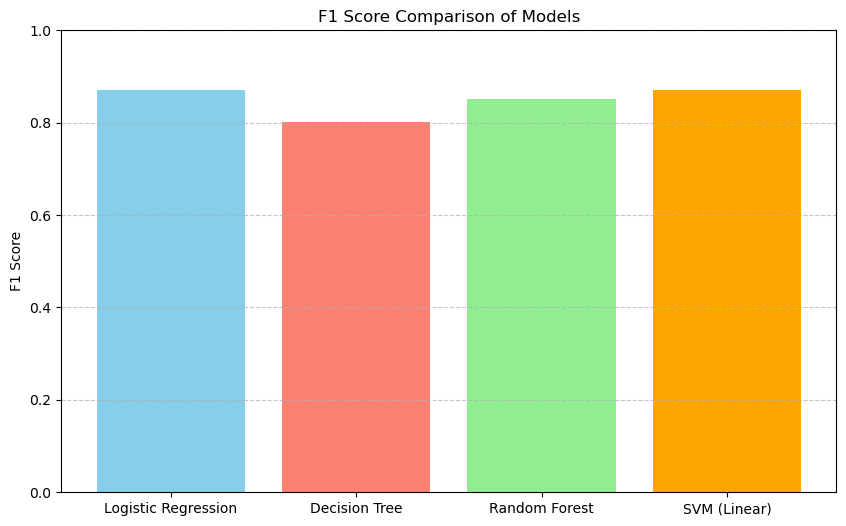

In [35]:
# ==============================
# Visualization of Model Comparison
# ==============================
plt.figure(figsize=(10,6))
plt.bar(df_comparison['Model'], df_comparison['F1 Score'], color=['skyblue', 'salmon', 'lightgreen', 'orange'])
plt.title('F1 Score Comparison of Models')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("f1_score_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

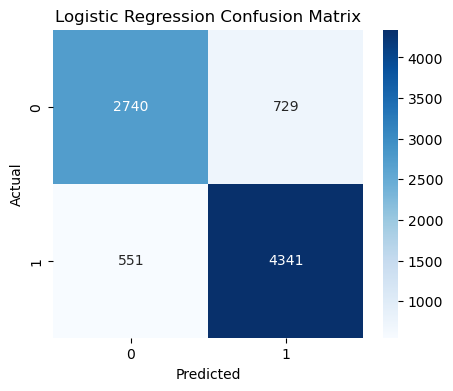

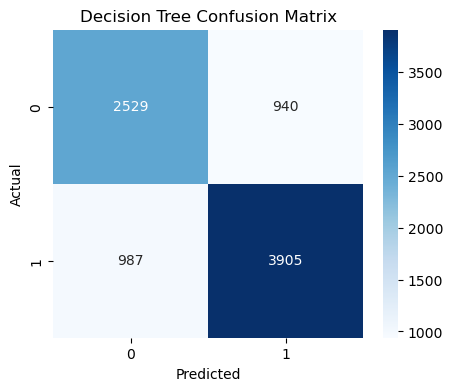

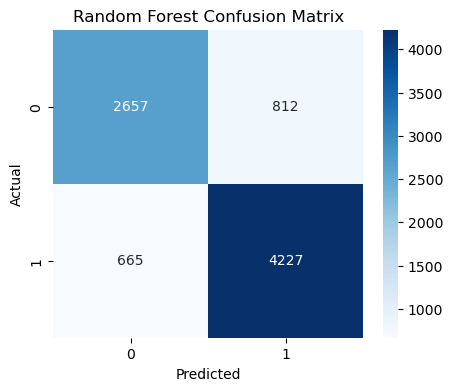

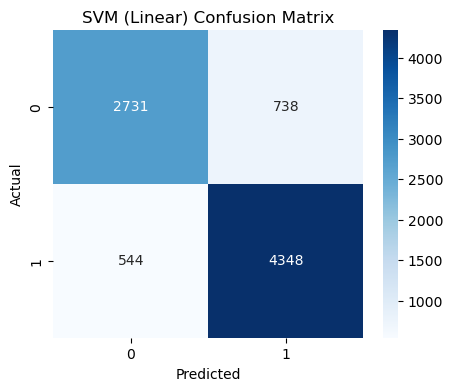

In [36]:
# ==============================
# Confusion Matrices Visualization
# ==============================
for name in model_results:
    cm = model_results[name]['Confusion Matrix']
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    filename = name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f"{filename}_confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.show()